<a href="https://colab.research.google.com/github/aburkov/theDRLbook/blob/main/continuous_ppo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PPO for Continuous Platform Lander

This notebook is self-contained in the same style as the earlier Colab notebooks: it installs `platform_lander` from PyPI, defines the continuous PPO implementation in notebook cells, and trains a tanh-squashed Gaussian actor with a learned critic.

In [ ]:
PLATFORM_LANDER_VERSION = '0.1.13'
!command -v swig >/dev/null || (apt-get -qq update > /dev/null && apt-get -qq install -y swig > /dev/null)
!python -m pip install --no-cache-dir -q "platform_lander[train]=={PLATFORM_LANDER_VERSION}"


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import csv
import hashlib
import math
import time
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions import Normal
import Box2D
import pygame
import importlib.metadata as md

from platform_lander import PlatformLander
from platform_lander.platform_lander import (
    BOOSTER_BOTTOM,
    BOOSTER_START_CLEARANCE,
    DEFAULT_WIND_POWER,
    SCALE,
    apply_booster_initial_impulse,
    sample_booster_start_angle,
)
import platform_lander.platform_lander as pl

installed_platform_lander_version = md.version('platform_lander')
assert installed_platform_lander_version == PLATFORM_LANDER_VERSION, installed_platform_lander_version

RUNS_DIR = Path('/content/runs') if Path('/content').exists() else Path('runs')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
EPISODES = 50_000
MAX_STEPS = 400
GAMMA = 0.99
TARGET_WINDOW = 50
PRINT_EVERY = 250
SAVE_EVERY = 1_000
NO_EARLY_STOP = False
RANDOM_BOOSTER_START_X = False

ENABLE_WIND = True
WIND_POWER = 3.0
SUCCESS_REWARD = 1000.0
FAILURE_REWARD = -300.0
SHAPING_FACTOR = 1.0
MAX_JET_FIRES = 50
EVALUATION_SEED = SEED + 10_000

print('torch:', torch.__version__)
print('numpy:', np.__version__)
print('box2d:', Box2D.__version__)
print('pygame:', pygame.version.ver)
print('platform_lander dist:', installed_platform_lander_version)
print('platform_lander file:', pl.__file__)
print('platform_lander sha256:', hashlib.sha256(Path(pl.__file__).read_bytes()).hexdigest())


pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
torch: 2.11.0+cpu
numpy: 2.0.2
box2d: 2.3.8
pygame: 2.6.1
platform_lander dist: 0.1.13
platform_lander file: /usr/local/lib/python3.12/dist-packages/platform_lander/platform_lander.py
platform_lander sha256: 4e24f4b359902c715ec81243dc32dfaa71aff6a2dbf38b4aa94689eb034bc63c


## Continuous Platform Lander

In continuous mode, `PlatformLander` uses a two-dimensional `Box(-1, 1)` action:

```text
action[0]: bottom-engine throttle, from off at -1 to full power at +1
action[1]: attitude jets, where the sign chooses left or right and magnitude chooses throttle
```

The observation is the same 11-dimensional state used by the discrete notebooks: relative position and velocity, angle and angular velocity, foot contacts, platform position and velocity, and remaining engine budget.

![](https://raw.githubusercontent.com/aburkov/theDRLbook/main/test_environments/platform_lander/booster_landing_stages.png)

The notebook pins `platform_lander==0.1.13`, the PyPI release containing the continuous-action environment update.


In [ ]:
def platform_lander_reward_kwargs() -> dict[str, float | int]:
    return {
        'success_reward': float(SUCCESS_REWARD),
        'failure_reward': float(FAILURE_REWARD),
        'shaping_factor': float(SHAPING_FACTOR),
        'max_jet_fires': int(MAX_JET_FIRES),
    }


def make_env(*, render_mode: str | None = None) -> PlatformLander:
    return PlatformLander(
        continuous=True,
        render_mode=render_mode,
        enable_wind=bool(ENABLE_WIND),
        wind_power=float(WIND_POWER),
        wind_direction=(1.0, 0.0),
        **platform_lander_reward_kwargs(),
    )


def randomize_start(
    env: PlatformLander,
    rng: np.random.Generator,
    *,
    random_booster_start_x: bool = False,
) -> np.ndarray:
    assert env.booster is not None
    assert env.platform is not None

    h = 400 / 30.0

    env.platform.position = (
        float(rng.uniform(env.platform_min_x, env.platform_max_x)),
        env.platform_y,
    )
    env.platform_direction = int(rng.choice([-1, 1]))
    env.platform.linearVelocity = (
        env.platform_speed * env.platform_direction,
        0.0,
    )

    booster_x = (
        float(rng.uniform(env.platform_min_x, env.platform_max_x))
        if random_booster_start_x
        else float(env.platform.position.x)
    )
    env.booster.position = (
        booster_x,
        float(h + BOOSTER_BOTTOM / SCALE + BOOSTER_START_CLEARANCE),
    )
    env.booster.angle = sample_booster_start_angle(rng)
    env.booster.linearVelocity = (0.0, 0.0)
    env.booster.angularVelocity = 0.0
    apply_booster_initial_impulse(env.booster, rng)
    env.booster.awake = True

    env.ocean_contact = False
    env.platform_contact = False
    env.body_platform_contact = False
    env.left_foot_contact = False
    env.right_foot_contact = False
    env.failure_reason = None
    env.prev_shaping = None
    env.bottom_flame_power = 0.0
    env.top_flame_power = 0.0
    env.top_flame_direction = 0
    env.jet_fires_used = 0
    return env._get_state()


def reset_env(env: PlatformLander, rng: np.random.Generator) -> np.ndarray:
    env.reset(seed=int(rng.integers(0, 2**31 - 1)))
    return randomize_start(
        env,
        rng,
        random_booster_start_x=RANDOM_BOOSTER_START_X,
    )


def step_timeout(
    env: PlatformLander,
    reward: float,
    done: bool,
    info: dict,
    step: int,
) -> tuple[float, bool, dict]:
    if step >= MAX_STEPS and not done:
        return float(env.failure_reward), True, {**info, 'success': False, 'failure_reason': 'timeout'}
    return float(reward), bool(done), info


def update_success_window(recent_successes: deque[bool], success: bool) -> tuple[int, bool]:
    recent_successes.append(bool(success))
    success_count = int(sum(recent_successes))
    solved = len(recent_successes) == TARGET_WINDOW and success_count == TARGET_WINDOW
    return success_count, solved


def save_csv(rows: list[dict[str, object]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        return
    fieldnames: list[str] = []
    for row in rows:
        for key in row:
            if key not in fieldnames:
                fieldnames.append(key)
    with path.open('w', encoding='utf-8', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def log(message: str, log_file=None) -> None:
    print(message, flush=True)
    if log_file is not None:
        log_file.write(message + '\n')
        log_file.flush()


In [ ]:
env = make_env()
observation, info = env.reset(seed=SEED)
print('observation_space:', env.observation_space)
print('action_space:', env.action_space)
print('initial observation shape:', observation.shape)
print('initial observation:', np.round(observation, 3))
print('sample continuous action:', np.round(env.action_space.sample(), 3))
env.close()


observation_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
   0.          0.         -1.         -2.          0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.         1.         2.         1.       ], (11,), float32)
action_space: Box([-1. -1.], [1. 1.], (2,), float32)
initial observation shape: (11,)
initial observation: [ 0.     1.474 -0.416  0.147  0.032  0.     0.     0.    -0.358  0.383
  1.   ]
sample continuous action: [-0.879  0.277]


## Gaussian Actor

The actor predicts a diagonal Gaussian over raw continuous actions. The raw action is passed through `tanh` so the final environment action always lies in `[-1, 1]`.

In [ ]:
ACTION_EPS = 1e-6


def init_layer(layer: nn.Linear, gain: float = math.sqrt(2.0)) -> nn.Linear:
    nn.init.orthogonal_(layer.weight, gain)
    nn.init.zeros_(layer.bias)
    return layer


def tanh_normal_log_prob(dist: Normal, raw_action: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
    correction = torch.log1p(-action.pow(2) + ACTION_EPS)
    return (dist.log_prob(raw_action) - correction).sum(dim=-1)


class GaussianPolicy(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        hidden_dim: int = 64,
        initial_log_std: float = -0.5,
        initial_bottom_mean: float = 0.0,
        initial_side_mean: float = 0.0,
    ) -> None:
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(obs_dim, hidden_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hidden_dim, hidden_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hidden_dim, action_dim), 0.01),
        )
        final_layer = self.net[-1]
        if isinstance(final_layer, nn.Linear):
            with torch.no_grad():
                if action_dim >= 1:
                    final_layer.bias[0] = float(initial_bottom_mean)
                if action_dim >= 2:
                    final_layer.bias[1] = float(initial_side_mean)
        self.log_std = nn.Parameter(torch.full((action_dim,), float(initial_log_std)))

    def forward(self, observations: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        mean = self.net(observations)
        log_std = self.log_std.expand_as(mean).clamp(-5.0, 2.0)
        return mean, log_std

    def distribution(self, observations: torch.Tensor) -> Normal:
        mean, log_std = self(observations)
        return Normal(mean, log_std.exp())

    def sample(self, observation: torch.Tensor) -> tuple[np.ndarray, torch.Tensor, torch.Tensor, torch.Tensor]:
        dist = self.distribution(observation)
        raw_action = dist.sample()
        action = torch.tanh(raw_action)
        log_prob = tanh_normal_log_prob(dist, raw_action, action)
        entropy = dist.entropy().sum(dim=-1)
        return action.detach().cpu().numpy().astype(np.float32), log_prob, entropy, raw_action

    def deterministic_action(self, observation: torch.Tensor) -> np.ndarray:
        mean, _log_std = self(observation)
        return torch.tanh(mean).detach().cpu().numpy().astype(np.float32)

    def log_prob_entropy(self, observations: torch.Tensor, raw_actions: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        dist = self.distribution(observations)
        actions = torch.tanh(raw_actions)
        return tanh_normal_log_prob(dist, raw_actions, actions), dist.entropy().sum(dim=-1)


In [ ]:
env = make_env()
observation, _ = env.reset(seed=SEED)
probe_policy = GaussianPolicy(
    int(env.observation_space.shape[0]),
    int(env.action_space.shape[0]),
)
action, log_prob, entropy, raw_action = probe_policy.sample(torch.as_tensor(observation, dtype=torch.float32))
print('sampled action:', np.round(action, 3))
print('log_prob:', float(log_prob.detach()))
print('entropy:', float(entropy.detach()))
env.close()


sampled action: [ 0.223 -0.174]
log_prob: -0.8743823766708374
entropy: 1.8378770351409912


## Value Critic

The critic estimates $V_\phi(o_t)$. PPO uses it both for generalized advantage estimation and as a supervised regression target during each update.

In [ ]:
class ValueFunction(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 64) -> None:
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(obs_dim, hidden_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hidden_dim, hidden_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hidden_dim, 1), 1.0),
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        return self.net(observations).squeeze(-1)


## Training

The implementation below collects parallel rollouts, computes GAE, and applies the clipped PPO objective over multiple minibatch epochs. The defaults match the continuous PPO settings used by the project validation driver.

In [ ]:
POLICY_LR = 0.0008
VALUE_LR = 0.00035
HIDDEN_DIM = 128
INITIAL_LOG_STD = -1.5
INITIAL_BOTTOM_MEAN = -1.5
INITIAL_SIDE_MEAN = 0.0
ENTROPY_COEF = 0.0
NORMALIZE_ADVANTAGES = True
NUM_ENVS = 12
ROLLOUT_STEPS = 384
GAE_LAMBDA = 0.97
PPO_EPOCHS = 8
MINIBATCH_SIZE = 64
CLIP_EPS = 0.1
LOG_FILE = RUNS_DIR / 'continuous_ppo.log'
CSV_FILE = RUNS_DIR / 'continuous_ppo.csv'
MODEL_FILE = RUNS_DIR / 'continuous_ppo.pt'


def compute_gae(
    value_function: ValueFunction,
    rewards: list[list[float]],
    dones: list[list[bool]],
    values: list[list[float]],
    next_observations: list[list[np.ndarray]],
) -> tuple[torch.Tensor, torch.Tensor]:
    advantages: list[float] = []
    returns: list[float] = []
    with torch.no_grad():
        for stream in range(len(rewards)):
            stream_len = len(rewards[stream])
            stream_advantages = [0.0 for _ in range(stream_len)]
            next_advantage = 0.0
            for t in reversed(range(stream_len)):
                if dones[stream][t]:
                    next_nonterminal = 0.0
                    next_value = 0.0
                else:
                    next_nonterminal = 1.0
                    if t + 1 < stream_len:
                        next_value = values[stream][t + 1]
                    else:
                        next_tensor = torch.as_tensor(next_observations[stream][t], dtype=torch.float32)
                        next_value = float(value_function(next_tensor).item())
                delta = rewards[stream][t] + GAMMA * next_nonterminal * next_value - values[stream][t]
                next_advantage = delta + GAMMA * GAE_LAMBDA * next_nonterminal * next_advantage
                stream_advantages[t] = next_advantage
            advantages.extend(stream_advantages)
            returns.extend(stream_advantages[t] + values[stream][t] for t in range(stream_len))
    return torch.as_tensor(advantages, dtype=torch.float32), torch.as_tensor(returns, dtype=torch.float32)


def train() -> tuple[GaussianPolicy, ValueFunction, pd.DataFrame]:
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    envs = [make_env() for _ in range(NUM_ENVS)]
    observations = [reset_env(env, rng) for env in envs]
    steps_in_episode = [0 for _ in envs]

    obs_dim = int(envs[0].observation_space.shape[0])
    action_dim = int(envs[0].action_space.shape[0])
    policy = GaussianPolicy(obs_dim, action_dim, HIDDEN_DIM, INITIAL_LOG_STD, INITIAL_BOTTOM_MEAN, INITIAL_SIDE_MEAN)
    value_function = ValueFunction(obs_dim, HIDDEN_DIM)
    policy_optimizer = torch.optim.Adam(policy.parameters(), lr=POLICY_LR)
    value_optimizer = torch.optim.Adam(value_function.parameters(), lr=VALUE_LR)

    recent_returns: deque[float] = deque(maxlen=TARGET_WINDOW)
    recent_successes: deque[bool] = deque(maxlen=TARGET_WINDOW)
    rows: list[dict[str, object]] = []
    episodes = 0
    updates = 0
    first50: int | None = None
    best_success50 = 0
    latest_return = [0.0 for _ in envs]
    latest_discount = [1.0 for _ in envs]
    latest_jet_fires = [0.0 for _ in envs]
    started_at = time.perf_counter()

    with LOG_FILE.open('w', encoding='utf-8') as log_file:
        log(f'training_start script=continuous_ppo episodes={EPISODES} num_envs={NUM_ENVS}', log_file)
        while episodes < EPISODES and (first50 is None or NO_EARLY_STOP):
            obs_buf: list[list[torch.Tensor]] = [[] for _ in envs]
            raw_action_buf: list[list[torch.Tensor]] = [[] for _ in envs]
            old_log_prob_buf: list[list[torch.Tensor]] = [[] for _ in envs]
            reward_buf: list[list[float]] = [[] for _ in envs]
            done_buf: list[list[bool]] = [[] for _ in envs]
            value_buf: list[list[float]] = [[] for _ in envs]
            next_obs_buf: list[list[np.ndarray]] = [[] for _ in envs]
            completed_returns: list[float] = []
            completed_records: list[dict[str, object]] = []

            for _ in range(ROLLOUT_STEPS):
                for i, env in enumerate(envs):
                    if episodes >= EPISODES:
                        break
                    obs_tensor = torch.as_tensor(observations[i], dtype=torch.float32)
                    with torch.no_grad():
                        dist = policy.distribution(obs_tensor)
                        raw_action = dist.sample()
                        action = torch.tanh(raw_action)
                        old_log_prob, _entropy = policy.log_prob_entropy(obs_tensor, raw_action)
                        value = value_function(obs_tensor)

                    next_obs, reward, terminated, truncated, info = env.step(action.detach().cpu().numpy().astype(np.float32))
                    steps_in_episode[i] += 1
                    done = bool(terminated or truncated)
                    reward, done, info = step_timeout(env, reward, done, info, steps_in_episode[i])
                    latest_return[i] += latest_discount[i] * float(reward)
                    latest_discount[i] *= GAMMA
                    latest_jet_fires[i] = float(info.get('jet_fires_used', latest_jet_fires[i]))

                    obs_buf[i].append(obs_tensor)
                    raw_action_buf[i].append(raw_action.detach())
                    old_log_prob_buf[i].append(old_log_prob.detach())
                    reward_buf[i].append(float(reward))
                    done_buf[i].append(done)
                    value_buf[i].append(float(value.item()))
                    next_obs_buf[i].append(np.asarray(next_obs, dtype=np.float32))

                    if done:
                        success = bool(info.get('success', False))
                        episodes += 1
                        episode_return = latest_return[i]
                        recent_returns.append(episode_return)
                        success_count, solved = update_success_window(recent_successes, success)
                        if len(recent_successes) == TARGET_WINDOW:
                            best_success50 = max(best_success50, success_count)
                        if solved:
                            first50 = episodes
                        completed_returns.append(episode_return)
                        completed_records.append(
                            {
                                'episode': episodes,
                                'return': episode_return,
                                'average_return': float(np.mean(recent_returns)),
                                'success_count': success_count,
                                'best_success50': best_success50,
                                'success_rate': success_count / len(recent_successes),
                                'success': success,
                                'last_success': success,
                                'steps': int(steps_in_episode[i]),
                                'last_steps': int(steps_in_episode[i]),
                                'jet_fires': float(latest_jet_fires[i]),
                                'last_jet_fires': float(latest_jet_fires[i]),
                                'first50': first50,
                            }
                        )
                        observations[i] = reset_env(env, rng)
                        steps_in_episode[i] = 0
                        latest_return[i] = 0.0
                        latest_discount[i] = 1.0
                        latest_jet_fires[i] = 0.0
                        if episodes >= EPISODES or (first50 is not None and not NO_EARLY_STOP):
                            break
                    else:
                        observations[i] = next_obs
                if episodes >= EPISODES or (first50 is not None and not NO_EARLY_STOP):
                    break

            flat_obs = [obs for stream in obs_buf for obs in stream]
            if not flat_obs:
                continue
            observation_tensor = torch.stack(flat_obs)
            raw_action_tensor = torch.stack([action for stream in raw_action_buf for action in stream])
            old_log_prob_tensor = torch.stack([lp for stream in old_log_prob_buf for lp in stream])
            advantages, returns = compute_gae(value_function, reward_buf, done_buf, value_buf, next_obs_buf)
            if NORMALIZE_ADVANTAGES and advantages.numel() > 1:
                advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)

            batch_size = int(observation_tensor.shape[0])
            minibatch_size = min(MINIBATCH_SIZE, batch_size)
            epoch_policy_losses: list[float] = []
            epoch_value_losses: list[float] = []
            epoch_entropies: list[float] = []
            epoch_clip_fractions: list[float] = []

            for _epoch in range(PPO_EPOCHS):
                indices = torch.randperm(batch_size)
                for start in range(0, batch_size, minibatch_size):
                    mb_idx = indices[start : start + minibatch_size]
                    new_log_probs, entropy = policy.log_prob_entropy(observation_tensor[mb_idx], raw_action_tensor[mb_idx])
                    ratio = torch.exp(new_log_probs - old_log_prob_tensor[mb_idx])
                    unclipped = ratio * advantages[mb_idx]
                    clipped = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * advantages[mb_idx]
                    policy_loss = -torch.minimum(unclipped, clipped).mean()
                    if ENTROPY_COEF:
                        policy_loss = policy_loss - ENTROPY_COEF * entropy.mean()
                    value_loss = F.mse_loss(value_function(observation_tensor[mb_idx]), returns[mb_idx])

                    policy_optimizer.zero_grad()
                    policy_loss.backward()
                    policy_optimizer.step()
                    value_optimizer.zero_grad()
                    value_loss.backward()
                    value_optimizer.step()

                    with torch.no_grad():
                        clip_fraction = ((ratio - 1.0).abs() > CLIP_EPS).float().mean().item()
                    epoch_policy_losses.append(float(policy_loss.detach().item()))
                    epoch_value_losses.append(float(value_loss.detach().item()))
                    epoch_entropies.append(float(entropy.detach().mean().item()))
                    epoch_clip_fractions.append(float(clip_fraction))
            updates += 1

            if completed_records:
                average_completed_return = float(np.mean(completed_returns))
                completed_episodes = len(completed_records)
                for record in completed_records:
                    row = {
                        **record,
                        'updates': updates,
                        'average_completed_return': average_completed_return,
                        'completed_episodes': completed_episodes,
                        'policy_loss': float(np.mean(epoch_policy_losses)),
                        'value_loss': float(np.mean(epoch_value_losses)),
                        'policy_entropy': float(np.mean(epoch_entropies)),
                        'clip_fraction': float(np.mean(epoch_clip_fractions)),
                    }
                    rows.append(row)
                row = rows[-1]
                if episodes == len(completed_records) or episodes % PRINT_EVERY < len(completed_records) or first50 is not None:
                    log(
                        f'episode={episodes:5d} update={updates:5d} avg{TARGET_WINDOW}={row["average_return"]:8.2f} '
                        f'success{TARGET_WINDOW}={int(row["success_count"]):2d} best_success50={int(row["best_success50"]):2d} '
                        f'last_success={int(row["last_success"])} steps={int(row["last_steps"]):4d} '
                        f'clipfrac={row["clip_fraction"]:.3f} first50={first50}',
                        log_file,
                    )
            if SAVE_EVERY and rows and episodes % SAVE_EVERY < max(1, len(completed_returns)):
                save_csv(rows, CSV_FILE)

        elapsed_seconds = time.perf_counter() - started_at
        if rows:
            rows[-1]['elapsed_seconds'] = elapsed_seconds
        save_csv(rows, CSV_FILE)
        torch.save({'policy_state_dict': policy.state_dict(), 'value_state_dict': value_function.state_dict()}, MODEL_FILE)
        log(f'training_done episodes={episodes} updates={updates} first50={first50} best_success50={best_success50}', log_file)
    for env in envs:
        env.close()
    return policy, value_function, pd.DataFrame(rows)


Run the training cell below. For a quick smoke test, reduce `EPISODES`, `NUM_ENVS`, `ROLLOUT_STEPS`, or `PPO_EPOCHS` above before running it.

In [ ]:
policy, value_function, history = train()
history.tail()


training_start script=continuous_ppo episodes=50000 num_envs=12
episode=   29 update=    1 avg50=  -68.64 success50= 5 best_success50= 0 last_success=0 steps= 116 clipfrac=0.122 first50=None
episode=  273 update=    9 avg50=  -39.43 success50= 9 best_success50=12 last_success=0 steps= 130 clipfrac=0.071 first50=None
episode=  519 update=   17 avg50=   34.83 success50=18 best_success50=22 last_success=0 steps= 134 clipfrac=0.085 first50=None
episode=  759 update=   25 avg50=    2.80 success50=15 best_success50=22 last_success=1 steps= 122 clipfrac=0.090 first50=None
episode= 1019 update=   33 avg50=   47.41 success50=18 best_success50=23 last_success=0 steps= 400 clipfrac=0.085 first50=None
episode= 1280 update=   41 avg50=   94.40 success50=23 best_success50=24 last_success=1 steps= 106 clipfrac=0.096 first50=None
episode= 1507 update=   48 avg50=   64.53 success50=21 best_success50=26 last_success=0 steps= 104 clipfrac=0.101 first50=None
episode= 1756 update=   56 avg50=   90.93 succe

,episode,return,average_return,success_count,best_success50,success_rate,success,last_success,steps,last_steps,...,last_jet_fires,first50,updates,average_completed_return,completed_episodes,policy_loss,value_loss,policy_entropy,clip_fraction,elapsed_seconds
5732,5733,352.291967,307.717537,49,49,0.98,True,True,100,100,...,20.406822,NaN,166,313.726918,44,0.002217,476.907081,-0.919808,0.163086,NaN
5733,5734,297.626249,306.466091,49,49,0.98,True,True,113,113,...,19.894848,NaN,166,313.726918,44,0.002217,476.907081,-0.919808,0.163086,NaN
5734,5735,258.116249,304.710753,49,49,0.98,True,True,118,118,...,22.170566,NaN,167,305.426829,3,-0.047867,465.744999,-0.928565,0.279741,NaN
5735,5736,323.788067,303.784618,49,49,0.98,True,True,105,105,...,27.856670,NaN,167,305.426829,3,-0.047867,465.744999,-0.928565,0.279741,NaN
5736,5737,334.376171,310.512080,50,50,1.00,True,True,96,96,...,18.952570,5737.0,167,305.426829,3,-0.047867,465.744999,-0.928565,0.279741,1097.95589


## Training Curves

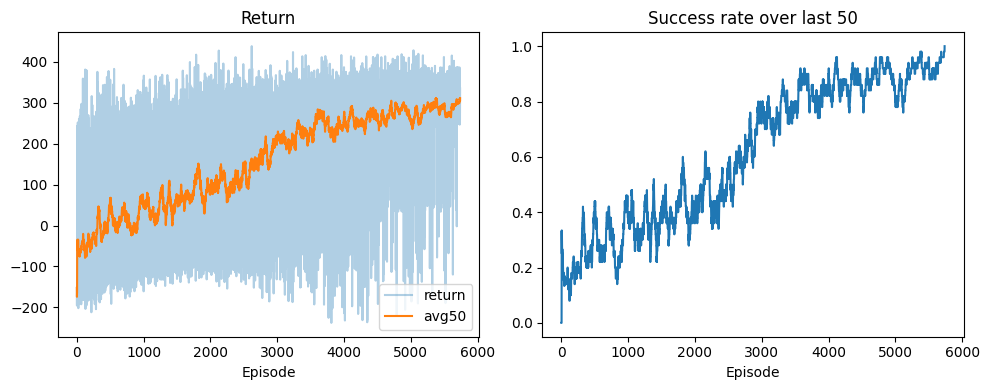

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history['episode'], history['return'], alpha=0.35, label='return')
axes[0].plot(history['episode'], history['average_return'], label=f'avg{TARGET_WINDOW}')
axes[0].set_title('Return')
axes[0].set_xlabel('Episode')
axes[0].legend()

axes[1].plot(history['episode'], history['success_rate'])
axes[1].set_title(f'Success rate over last {TARGET_WINDOW}')
axes[1].set_xlabel('Episode')
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


## Deterministic Evaluation

In [ ]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation


def evaluate_policy(policy: GaussianPolicy, *, seed: int = EVALUATION_SEED, render: bool = True):
    policy.eval()
    rng = np.random.default_rng(seed)
    env = make_env(render_mode='rgb_array' if render else None)
    observation = reset_env(env, rng)
    frames: list[np.ndarray] = []
    rewards: list[float] = []
    info: dict = {}
    try:
        with torch.no_grad():
            for step in range(1, MAX_STEPS + 1):
                obs_tensor = torch.as_tensor(observation, dtype=torch.float32)
                action = policy.deterministic_action(obs_tensor)
                observation, reward, terminated, truncated, info = env.step(action)
                done = bool(terminated or truncated)
                reward, done, info = step_timeout(env, reward, done, info, step)
                rewards.append(float(reward))
                if render:
                    frames.append(env.render())
                if done:
                    break
    finally:
        env.close()
    return frames, rewards, float(sum(rewards)), info


frames, rewards, total_return, info = evaluate_policy(policy)
print(f'evaluation_return={total_return:.2f} steps={len(rewards)} info={info}')

if frames:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')
    image = ax.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return (image,)

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / 30, blit=True)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))


evaluation_return=789.42 steps=99 info={'success': True, 'failure_reason': None, 'platform_x': 9.571242332458496, 'platform_impact_velocity': (1.1839263439178467, -9.09229564666748, -0.35189124941825867), 'success_reward_multiplier': 0.7109894411904472, 'wind_power': 3.0, 'wind_direction': (1.0, 0.0), 'jet_fires_used': 6.459902597591281, 'jet_fires_remaining': 43.54009740240872, 'stable_landing_steps': 0, 'anchored_feet': ('left_foot', 'right_foot'), 'left_foot_contact': True, 'right_foot_contact': True, 'body_platform_contact': False, 'platform_contact': True}


evaluation_return=789.42 steps=99 info={'success': True, 'failure_reason': None, 'platform_x': 9.571242332458496, 'platform_impact_velocity': (1.1839263439178467, -9.09229564666748, -0.35189124941825867), 'success_reward_multiplier': 0.7109894411904472, 'wind_power': 3.0, 'wind_direction': (1.0, 0.0), 'jet_fires_used': 6.459902597591281, 'jet_fires_remaining': 43.54009740240872, 'stable_landing_steps': 0, 'anchored_feet': ('left_foot', 'right_foot'), 'left_foot_contact': True, 'right_foot_contact': True, 'body_platform_contact': False, 'platform_contact': True}


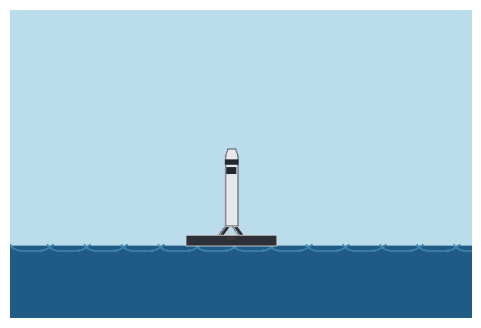

In [ ]:
frames, rewards, total_return, info = evaluate_policy(policy)
print(f'evaluation_return={total_return:.2f} steps={len(rewards)} info={info}')
if frames:
    plt.figure(figsize=(6, 4))
    plt.imshow(frames[-1])
    plt.axis('off')
    plt.show()
